In [2]:
from google.colab import files

uploaded = files.upload()


Saving cleaned_dataset.csv to cleaned_dataset.csv


In [3]:
import pandas as pd

df = pd.read_csv("cleaned_dataset.csv")

In [4]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Order Year,Order Month,Profit Margin %
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.809686,12.031393
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.284654,46.675435
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,-275.000000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,5.000000,7.500000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,9.000000,27.000000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,11.000000,36.250000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,50.000000


In [5]:
print(df['Category'].value_counts())
print(df['Region'].value_counts())
print(df['Segment'].value_counts())

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64


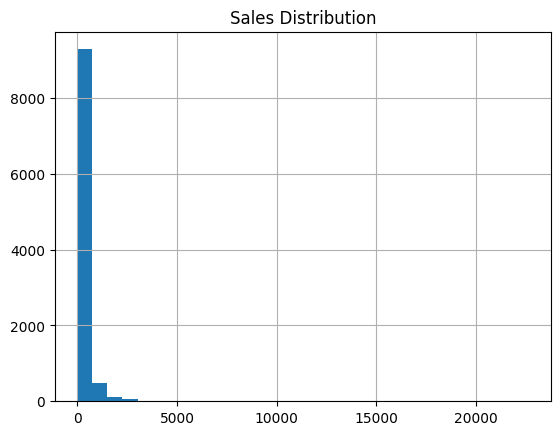

In [6]:
import matplotlib.pyplot as plt

df['Sales'].hist(bins=30)
plt.title("Sales Distribution")
plt.show()

In [11]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


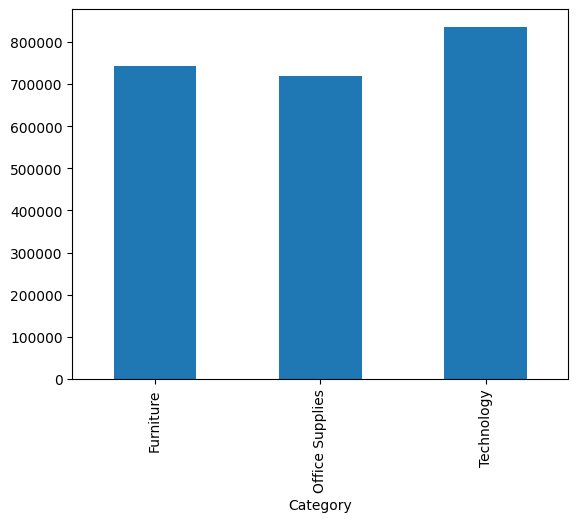

In [7]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.show()

In [12]:
df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

,Profit
Region,
West,108418.4489
East,91522.7800
South,46749.4303
Central,39706.3625


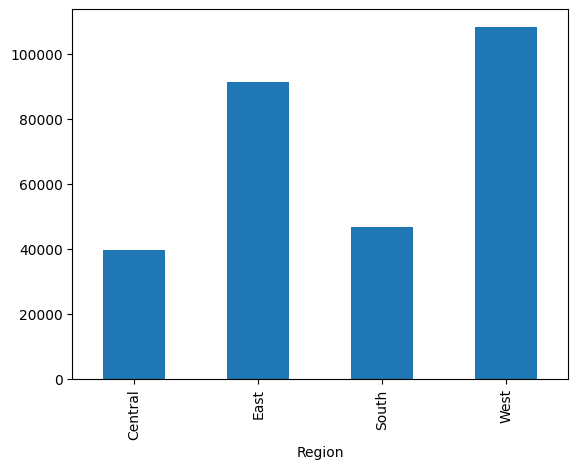

In [8]:
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.show()

In [13]:
df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


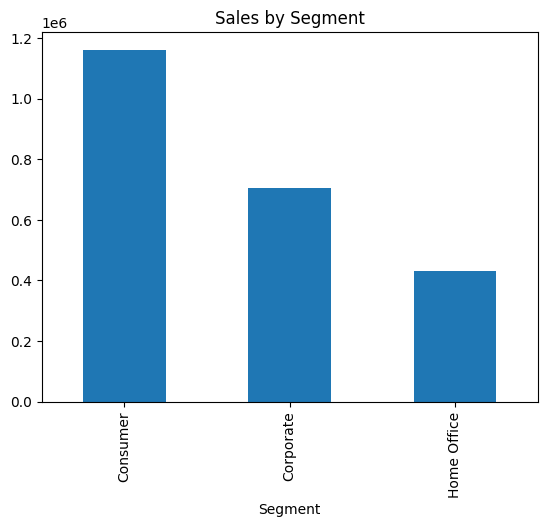

In [14]:
df.groupby('Segment')['Sales'].sum().plot(kind='bar')
plt.title('Sales by Segment')
plt.show()

In [15]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


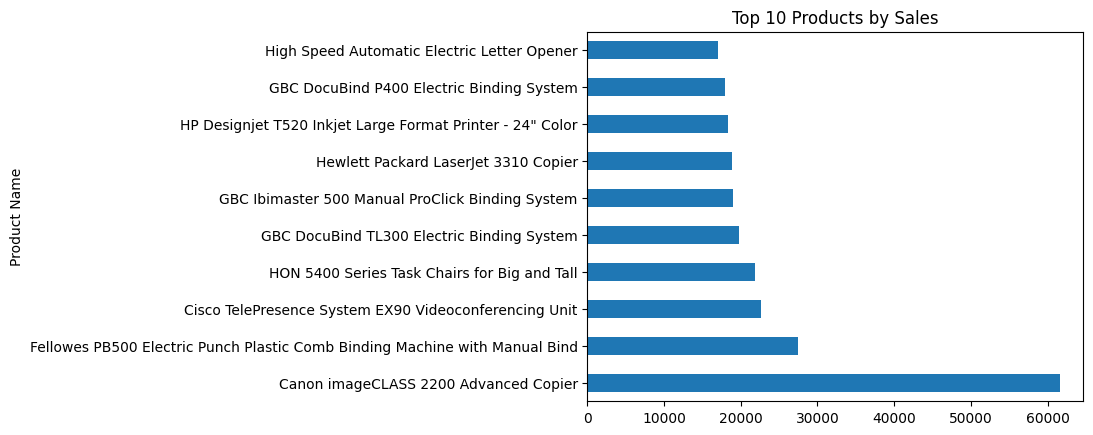

In [16]:
top_products.plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.show()

In [17]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_customers)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64


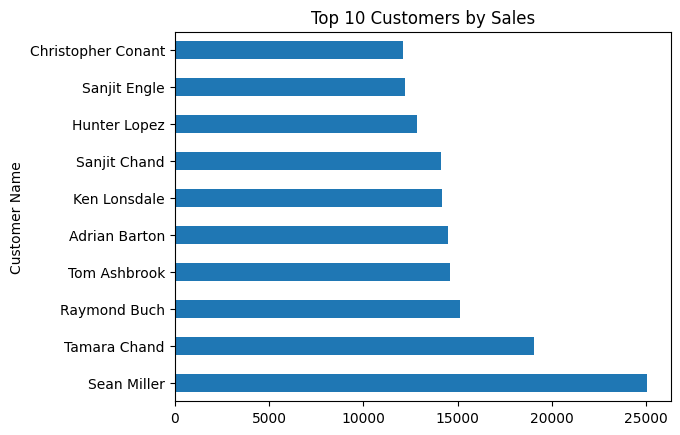

In [18]:
top_customers.plot(kind='barh')
plt.title('Top 10 Customers by Sales')
plt.show()

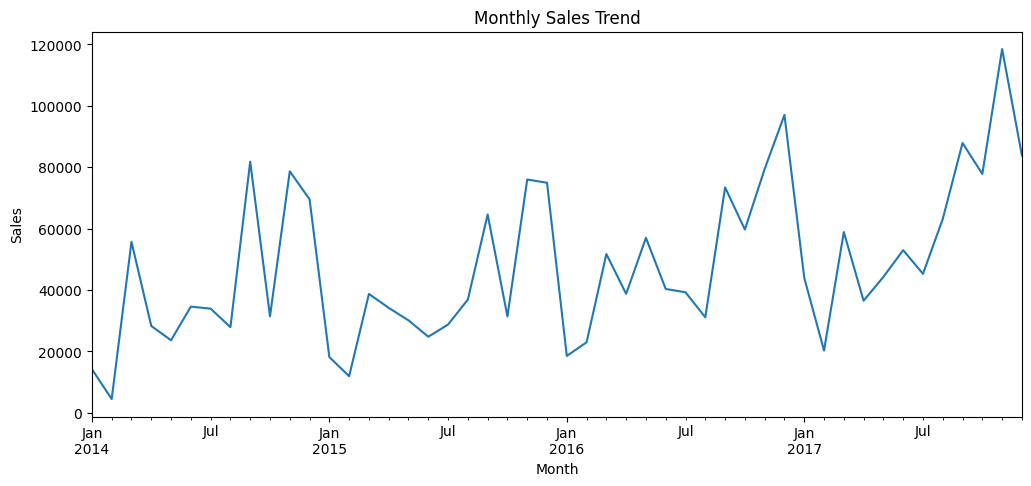

In [19]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(figsize=(12,5))
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [20]:
top_states = df.groupby('State')['Profit'].sum().sort_values(ascending=False).head(10)

print(top_states)

State
California    76381.3871
New York      74038.5486
Washington    33402.6517
Michigan      24463.1876
Virginia      18597.9504
Indiana       18382.9363
Georgia       16250.0433
Kentucky      11199.6966
Minnesota     10823.1874
Delaware       9977.3748
Name: Profit, dtype: float64


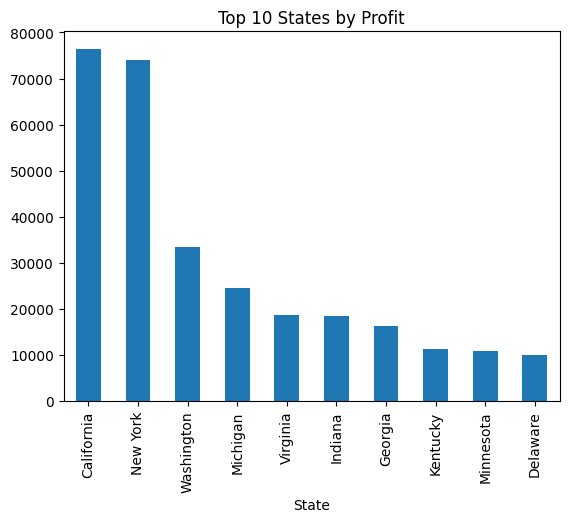

In [21]:
top_states.plot(kind='bar')
plt.title('Top 10 States by Profit')
plt.show()

In [22]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


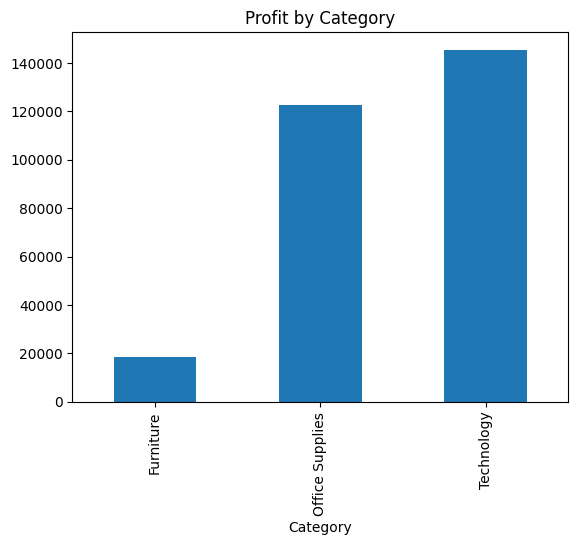

In [23]:
df.groupby('Category')['Profit'].sum().plot(kind='bar')
plt.title('Profit by Category')
plt.show()

In [24]:
df['Ship Mode'].value_counts()

,count
Ship Mode,
Standard Class,5968
Second Class,1945
First Class,1538
Same Day,543


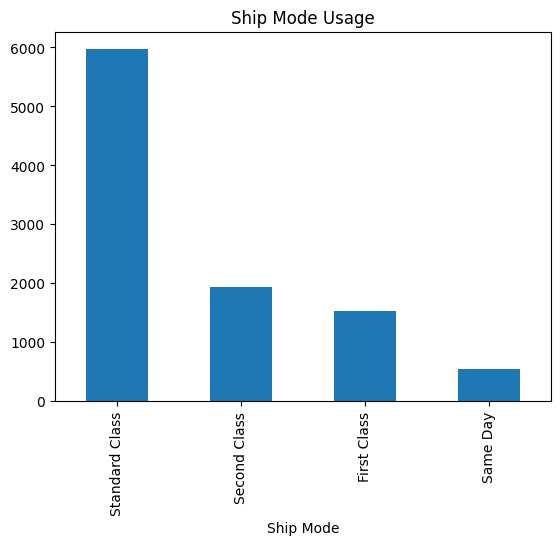

In [25]:
df['Ship Mode'].value_counts().plot(kind='bar')
plt.title('Ship Mode Usage')
plt.show()

In [26]:
df.groupby('Category')['Discount'].mean().sort_values(ascending=False)

,Discount
Category,
Furniture,0.173923
Office Supplies,0.157285
Technology,0.132323


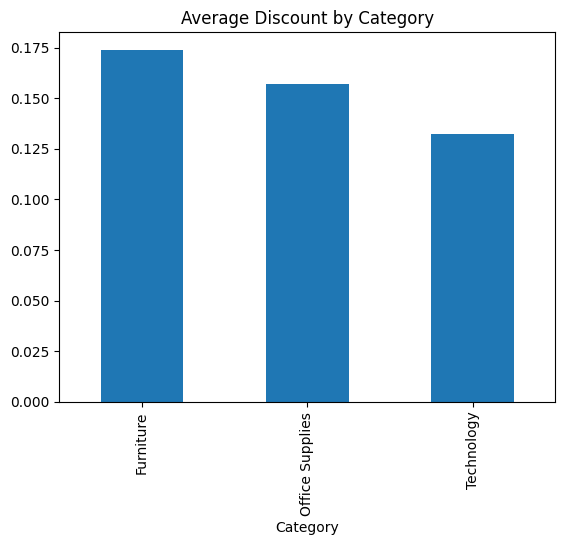

In [27]:
df.groupby('Category')['Discount'].mean().plot(kind='bar')
plt.title('Average Discount by Category')
plt.show()

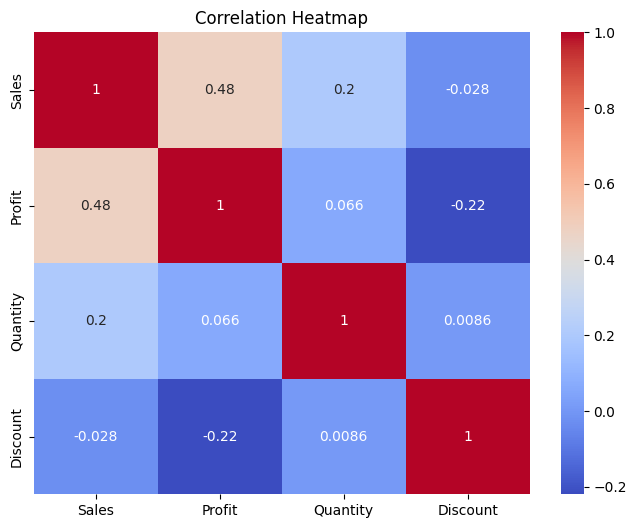

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['Sales','Profit','Quantity','Discount']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

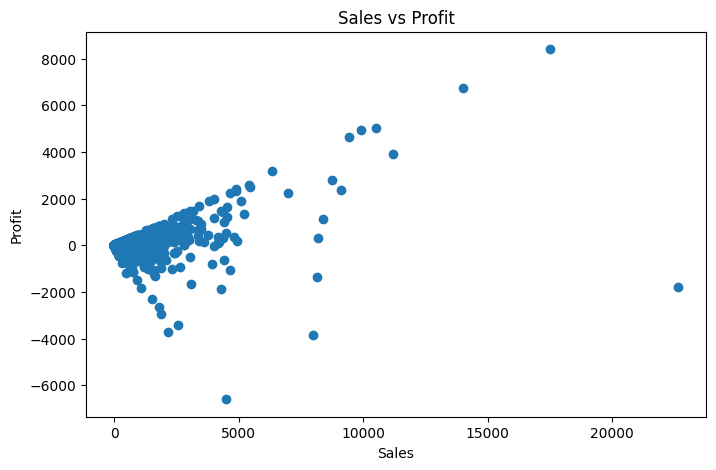

In [29]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Profit'])
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.title('Sales vs Profit')
plt.show()

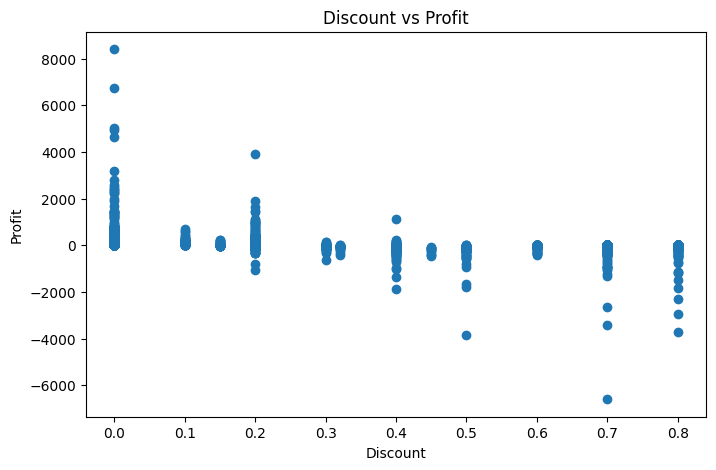

In [30]:
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'])

plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')

plt.show()

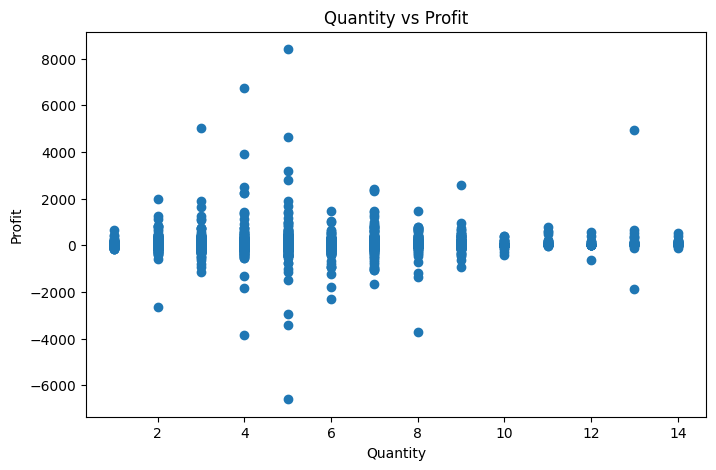

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(df['Quantity'], df['Profit'])

plt.xlabel('Quantity')
plt.ylabel('Profit')
plt.title('Quantity vs Profit')

plt.show()

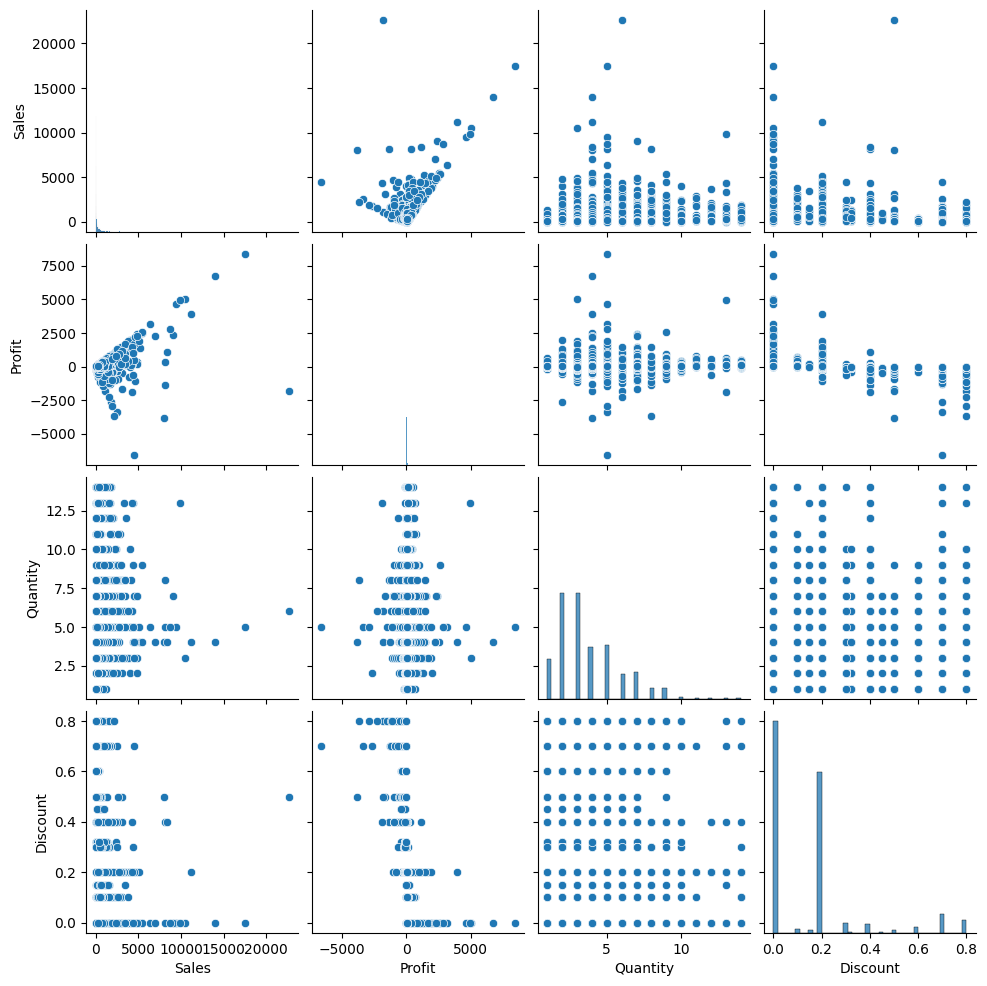

In [32]:
sns.pairplot(df[['Sales','Profit','Quantity','Discount']])

plt.show()

In [33]:
category_analysis = df.groupby('Category')[['Sales','Profit']].sum()

print(category_analysis)

                       Sales       Profit
Category                                 
Furniture        741999.7953   18451.2728
Office Supplies  719047.0320  122490.8008
Technology       836154.0330  145454.9481


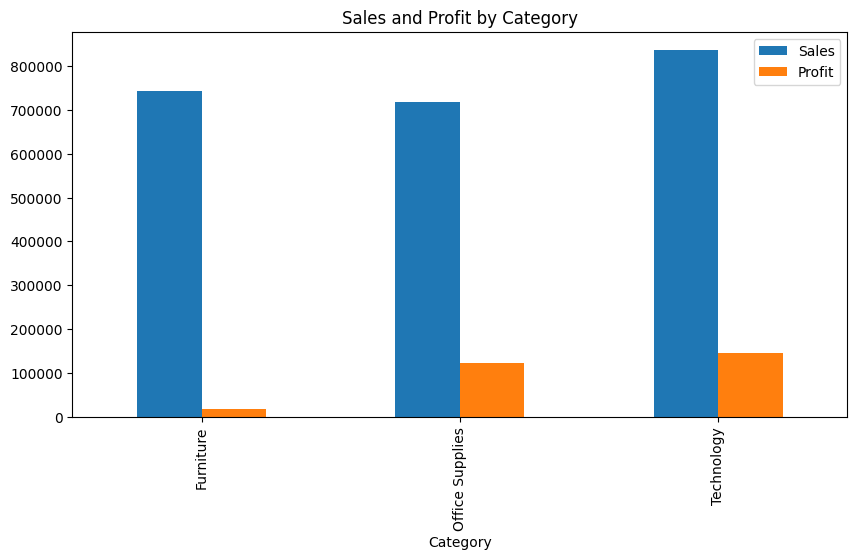

In [34]:
category_analysis.plot(kind='bar', figsize=(10,5))
plt.title('Sales and Profit by Category')
plt.show()

In [35]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()

print("Total Sales:", total_sales)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)

Total Sales: 2297200.8603000003
Total Profit: 286397.0217
Total Orders: 5009


In [39]:
sns.heatmap(...)

ValueError: Must pass 2-d input. shape=()